## Data Analysis - Answering Questions

### Business Questions
- What is the churn rate by contract type, payment method, and internet service type?
- What is the average tenure and monthly charge for churned vs. retained customers?
- Which customers combine a month-to-month contract with high monthly charges?
- Which subscribed services are most associated with churn?

### Diagnostic Analysis
- Bucket customers into tenure groups (e.g., 0–12, 13–24, 25–48, 48+ months) and compute churn rate per bucket
- Find the churn rate for combinations of two categorical features (e.g., contract type × payment method) to identify the highest-risk segments


In [1]:
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical operations and arrays
import matplotlib.pyplot as plt  # Data visualization and plotting

# Loading Dataset And Adjusting Options
df = pd.read_csv('D:/Data Analyst Resources/End-To-End Projects/Telecom Customer Churn Project/Data/TelcoCustomerChurnRawData.csv')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## Business Questions

### What is the churn rate by contract type, payment method, and internet service type?

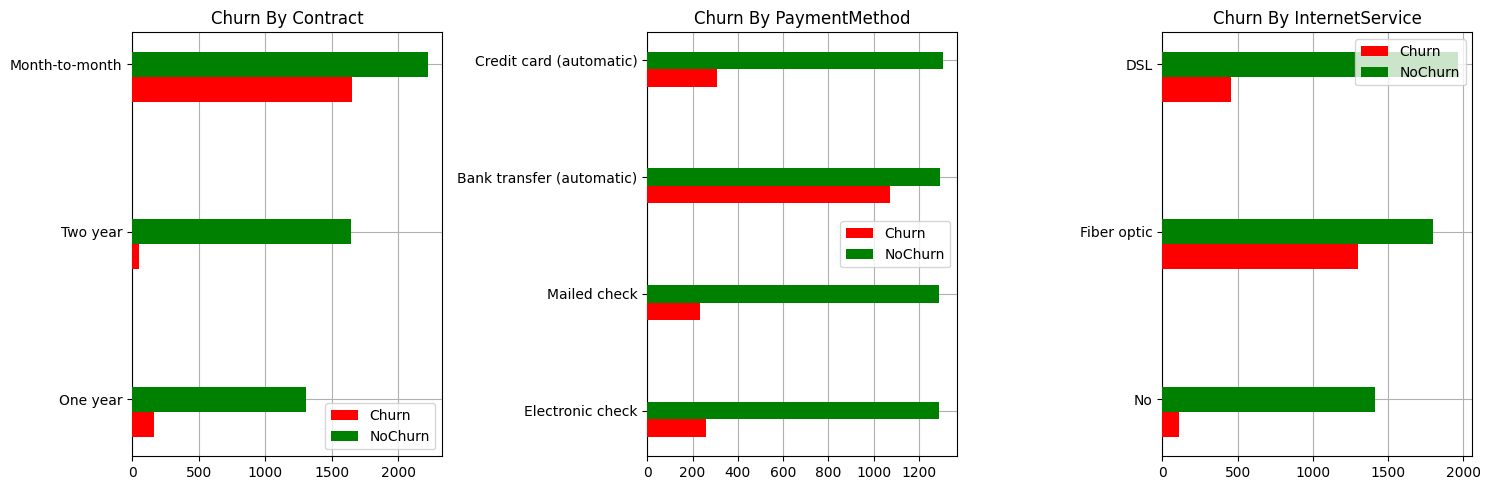

In [2]:
df[['Churn','Contract','PaymentMethod','InternetService']]
cols = ['Contract','PaymentMethod','InternetService']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ind = [0,1,2]

for i,baz in zip(ind,cols) :
    x = df.groupby(baz)['Churn'].value_counts()
    contracts = df[baz].unique()
    churn = []
    No_churn = []

    for (foo,bar),cnt in x.items():
        if bar == "No":
            No_churn.append(cnt)
        else:
            churn.append(cnt)

    order = np.argsort(No_churn)
    contracts = np.array(contracts)[order]
    churn = np.array(churn)[order]
    No_churn = np.array(No_churn)[order]

    y = np.arange(len(contracts))
    axes[i].barh(y-0.15,churn,height=0.15 ,color = 'red', zorder = 3 ,label = 'Churn')
    axes[i].barh(y,No_churn,height=0.15, color = 'green', zorder = 3 ,label = 'NoChurn' )
    axes[i].set_yticks(ticks=y,labels=contracts)
    axes[i].legend()
    axes[i].set_title(f"Churn By {baz}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

##### 🔎 Key Insight

Month-to-month customers have a significantly higher churn rate compared with customers on one-year and two-year contracts. Similarly, customers using bank transfers and fiber-optic internet services show higher churn rates compared with other categories.

The results indicate that contract type, payment method, and internet service type are associated with differences in customer churn. In particular, the higher churn rate among month-to-month customers suggests that customers without long-term contracts may be more likely to leave. The higher churn observed among bank-transfer and fiber-optic customers also identifies these groups as segments that may require further investigation.


### What is the average tenure and monthly charge for churned vs. retained customers?

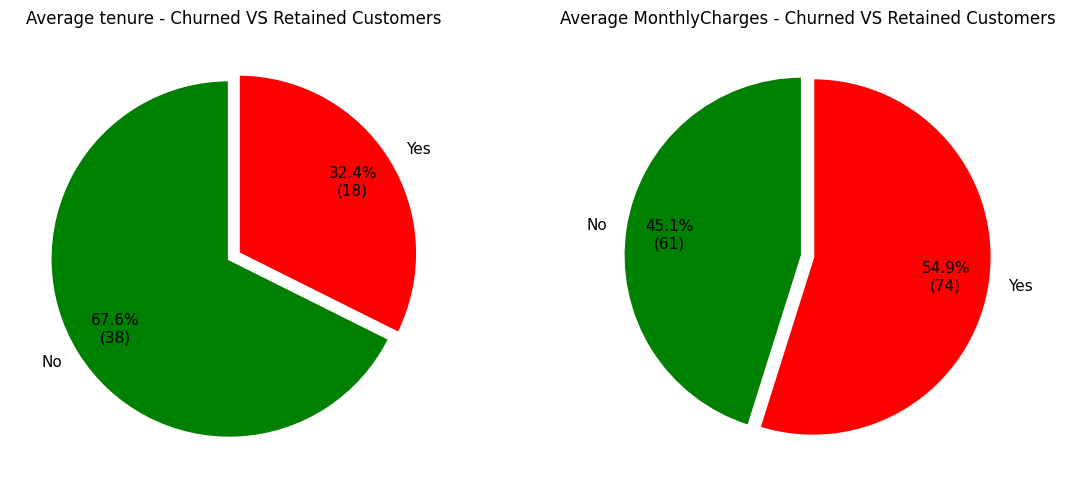

In [3]:
df[['tenure','MonthlyCharges','Churn']]

x = df.groupby('Churn')[['tenure','MonthlyCharges']].agg(['mean'])
cols = ['tenure','MonthlyCharges']

fig,axes = plt.subplots(1,2,figsize = (12,5))

for i,col in enumerate(cols):
    ind = list(x[col].index)
    val = x[col]['mean'].values.tolist()
    axes[i].pie(
        val,
        labels=ind,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(val)/100:.0f})',
        startangle=90,
        explode=[0.03] * len(val),
        pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 11},
        colors = ['green','red']
    )
    axes[i].set_title(f"Average {col} - Churned VS Retained Customers")

plt.tight_layout()
plt.show()

##### 🔎 Key Insight

Churned customers had a significantly lower average tenure of approximately 18 months compared with 38 months for retained customers. At the same time, churned customers had higher average monthly charges ($74) compared with retained customers ($61).


The results indicate that customers with shorter tenure and higher monthly charges are more strongly associated with churn. This suggests that newer customers with relatively higher monthly costs may represent an important segment to investigate further.


### Which customers combine a month-to-month contract with high monthly charges?

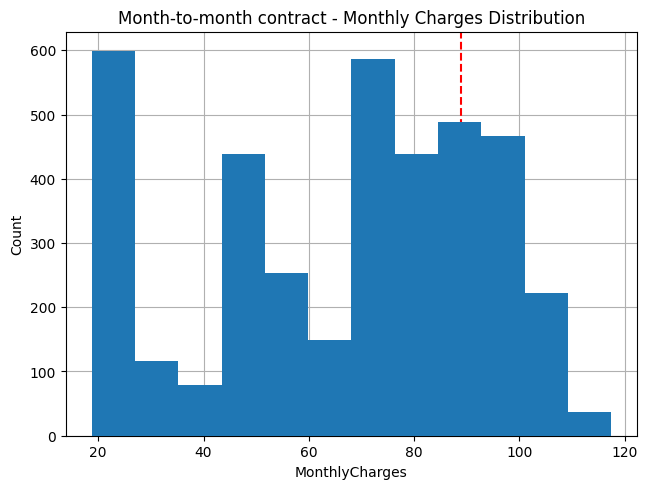

In [4]:
df[['Contract','MonthlyCharges']]
x = df.loc[df['Contract'] == 'Month-to-month' , ['Contract','MonthlyCharges'] ]

highMonthlyChargesVal = x['MonthlyCharges'].quantile(0.75)

plt.hist(x['MonthlyCharges'],bins=12 , zorder =3 , )
plt.axvline(
    highMonthlyChargesVal,
    linestyle='--',
    label='75th percentile',
    color = 'red'
)
plt.title('Month-to-month contract - Monthly Charges Distribution')
plt.tight_layout()
plt.xlabel('MonthlyCharges')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### Which subscribed services are most associated with churn?

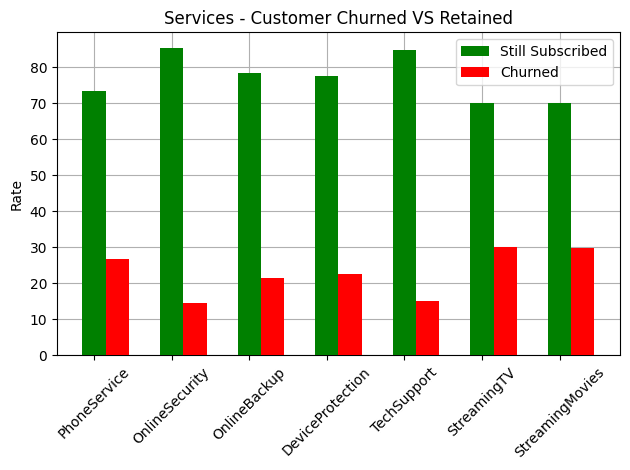

In [5]:
df[['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']]

colsNeeded = ['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
NoChurn = []
Churn = []
totalCus = []

for col in colsNeeded:
    totalCus.append(  df[ df[col] == 'Yes' ].shape[0] )
    NoChurn.append( (df[ df[col] == 'Yes' ].groupby('Churn')['Churn'].agg('count').to_dict())['No']/totalCus[-1]*100 )
    Churn.append( (df[ df[col] == 'Yes' ].groupby('Churn')['Churn'].agg('count').to_dict())['Yes']/totalCus[-1]*100 )

y = np.arange(len(colsNeeded))
plt.bar(y,NoChurn,width=0.3,color='green',zorder = 3 , label = 'Still Subscribed')
plt.bar(y+0.3,Churn,width=0.3,color='red' , zorder = 3 , label = 'Churned')
plt.title('Services - Customer Churned VS Retained')
plt.xticks(y,labels=colsNeeded , rotation = 45)
plt.ylabel('Rate')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

#### 🔎 Key Insight

Streaming TV and Streaming Movies have the highest churn rates among the analyzed services, at approximately 30% each, followed by Phone Service at 27%.


The results indicate that customers subscribed to Streaming TV and Streaming Movies are associated with higher churn rates, while Phone Service also shows a relatively high churn rate. These services may represent customer segments that require further investigation to understand the factors contributing to their higher churn.


## Diagnostic Questions

### Q1. Bucket customers into tenure groups (e.g., 0–12, 13–24, 25–48, 48+ months) and compute churn rate per bucket

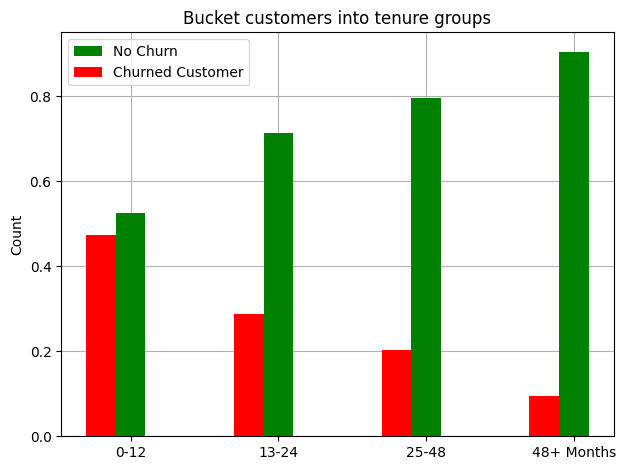

In [6]:
def BucketCust( cat ):
    if cat >= 0 and cat <= 12:
        return '0-12'
    elif cat >= 13 and cat <= 24:
        return '13-24'
    elif cat >= 25 and cat <= 48:
        return '25-48'
    else:
        return '48+ Months'

df['BucketCustCol'] = df['tenure'].apply(BucketCust)
foo = df.groupby(['BucketCustCol'])['Churn'].value_counts(normalize= True).to_dict()

buckets = ['0-12','13-24','25-48','48+ Months']
NoChurn = []
Churn = []

for (foo1,foo2),baz in foo.items():
    if foo2 == 'No':
        NoChurn.append(baz)
    else:
        Churn.append(baz)

y = np.arange(len(buckets))

plt.bar(y,NoChurn,width = 0.2,zorder = 3, color= 'green' , label = 'No Churn')
plt.bar(y-0.2,Churn, width= 0.2,zorder = 3 , color = 'red', label = 'Churned Customer')
plt.grid(True)
plt.title('Bucket customers into tenure groups')
plt.xticks(y,labels=buckets)
plt.ylabel('Count')
plt.tight_layout()
plt.legend()
plt.show()

##### 🔎 Key Insight

Customers with 0–12 months of tenure have the highest churn rate at approximately 44%. The churn rate consistently decreases as customer tenure increases, reaching its lowest level among customers with 48+ months of tenure.

The results indicate a clear association between customer tenure and churn. Newer customers appear to be considerably more likely to churn, while customers who have been with the company longer tend to show lower churn rates. This suggests that the early stages of the customer relationship may be particularly important for retention.


### Q3. Find the churn rate for combinations of two categorical features (e.g., contract type × payment method) to identify the highest-risk segments

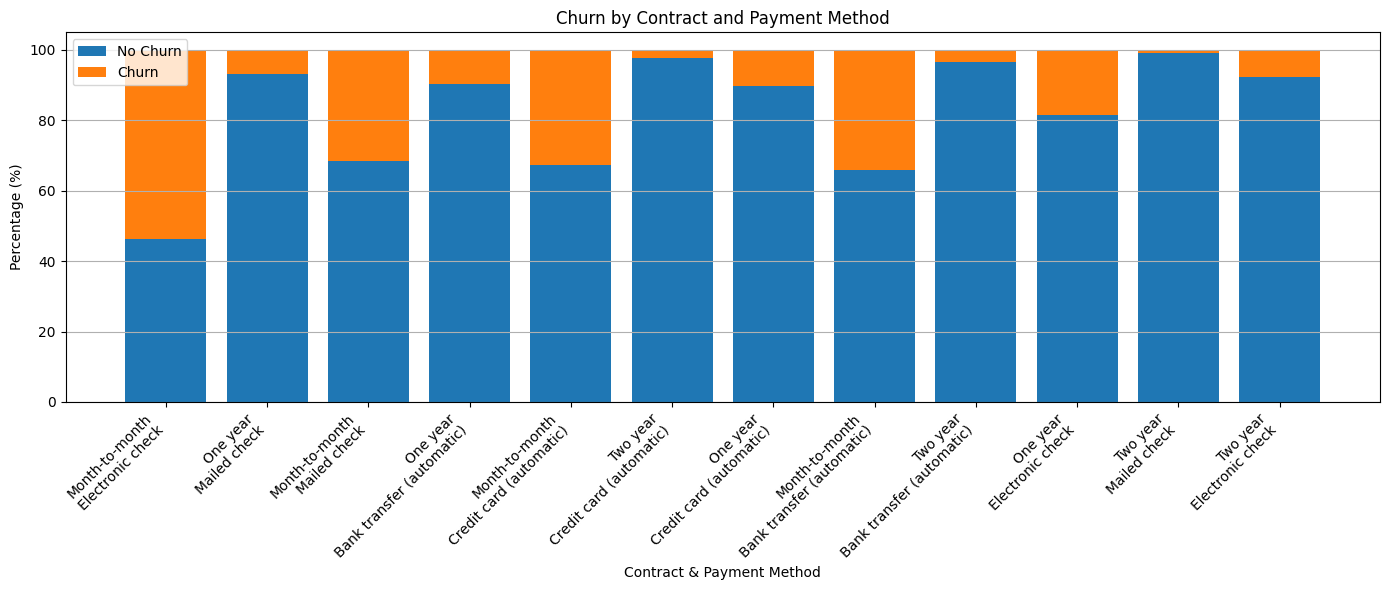

In [7]:
df.columns
foo = df.groupby(['Contract','PaymentMethod'])['Churn'].value_counts(normalize= True).to_dict()

foo = df.groupby(
    ['Contract', 'PaymentMethod']
)['Churn'].value_counts(normalize=True).to_dict()

labels = []
NoChurn = []
Churn = []

pairs = df[['Contract', 'PaymentMethod']].drop_duplicates()
for contract, payment in pairs.values:
    labels.append(f'{contract}\n{payment}')
    NoChurn.append(foo.get((contract, payment, 'No'), 0) * 100)
    Churn.append(foo.get((contract, payment, 'Yes'), 0) * 100)

x = np.arange(len(labels))
plt.figure(figsize=(14, 6))
plt.bar(x,NoChurn,label='No Churn')
plt.bar(x,Churn,bottom=NoChurn,label='Churn')
plt.xticks(x,labels,rotation=45,ha='right')
plt.ylabel('Percentage (%)')
plt.xlabel('Contract & Payment Method')
plt.title('Churn by Contract and Payment Method')
plt.grid(axis='y', zorder=0)
plt.legend()
plt.tight_layout()
plt.show()

#### 🔎 Key Insight

Customers on month-to-month contracts show the highest churn rates, particularly among those using electronic check payments. In comparison, the other combinations of contract type and payment method show noticeably lower churn rates.

The results indicate that contract type and payment method are associated with differences in customer churn. The combination of a month-to-month contract and electronic check appears to represent a higher-churn customer segment that may require further investigation.
